<a href="https://colab.research.google.com/github/Ab-126/Machine_Learning/blob/main/Ridge_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ridge Regression From Scratch, For m and b

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

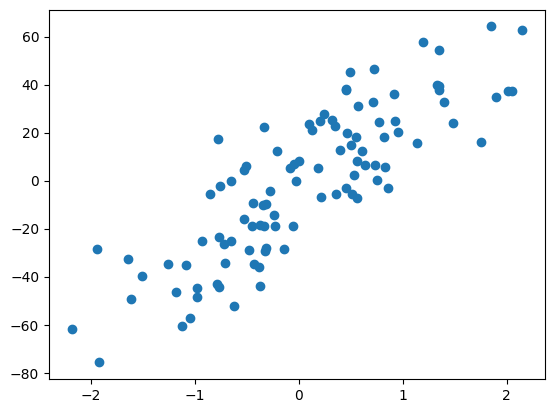

In [3]:
plt.scatter(X, y)

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [7]:
from sklearn.linear_model import Ridge

In [8]:
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235735


In [10]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


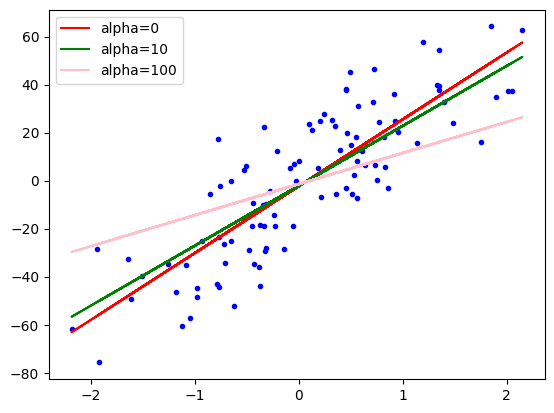

In [14]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='pink',label='alpha=100')
plt.legend()

In [15]:
def linear_regression(X,y,alpha=1):
    x_mean = X.mean()
    y_mean = y.mean()

    num = 0
    den = 0

    for i in range(X.shape[0]):
        num = num + (y[i] - y_mean) * (X[i] - x_mean)
        den = den + (X[i] - x_mean) * (X[i] - x_mean)

    m = num/(den + alpha)
    b = y_mean - m*x_mean

    return m,b

In [16]:
class MeraRidge:

    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self,X_train,y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())

        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m,self.b)

    def predict(X_test):
        pass

In [18]:
reg = MeraRidge(alpha=100)
reg.fit(X,y)

[12.93442104] [-1.42484415]


# Ridge Regression From Scratch

In [19]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [20]:
X,y = load_diabetes(return_X_y=True)

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [22]:
from sklearn.linear_model import Ridge

In [24]:
reg = Ridge(alpha=0.1,solver='cholesky')
reg.fit(X_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

In [25]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4693128853309805

In [26]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [28]:
class MeraRidge:
  def __init__(self, alpha=0.1):
    self.alpha = alpha
    self.coef_ = None
    self.intercept_ = None

  def fit(self, X_train, y_train):
    X_train = np.insert(X_train, 0, 1, axis=1)
    I = np.identity(X_train.shape[1])
    I[0][0] = 0
    result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
    self.intercept_ = result[0]
    self.coef_ = result[1:]

  def predict(self, X):
    return np.dot(X_test,self.coef_) + self.intercept_

In [29]:
reg = MeraRidge()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.4693128853309805
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.8905342560281


# Ridge Regression using Gradient Descent

In [30]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [31]:
X,y = load_diabetes(return_X_y=True)

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [34]:
from sklearn.linear_model import SGDRegressor

In [36]:
reg = SGDRegressor(penalty='l2', max_iter=500, eta0=0.01, learning_rate='constant', alpha=0.001)

In [37]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.43114002380470506
[  57.75854558  -85.41482183  302.02684367  226.30931306   24.63441677
  -16.57125586 -157.54026852  141.70964101  275.80046475  117.0045832 ]
[152.67253943]


In [38]:
from sklearn.linear_model import Ridge

reg = Ridge(alpha=0.001, max_iter=500,solver='sparse_cg')

In [39]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.46250101619914563
[  34.52192544 -290.84084076  482.40181344  368.0678662  -852.44873179
  501.59160336  180.11115788  270.76333979  759.73534372   37.4913546 ]
151.10198517439466


In [59]:
class MeraRidgeGD:
  def __init__(self, epochs, learning_rate, alpha):
    self.learning_rate = learning_rate
    self.alpha = alpha
    self.epochs = epochs
    self.coef_ = None
    self.intercept_ = None

  def fit(self, X_train, y_train):
    self.coef_ = np.ones(X_train.shape[1])
    self.intercept_ = 0
    thetha = np.insert(self.coef_, 0, self.intercept_)
    print('theta', thetha)

    X_train = np.insert(X_train,0,1,axis=1)
    print('X_train', X_train)

    for i in range(self.epochs):
      thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
      thetha = thetha - self.learning_rate*thetha_der

    self.coef_ = thetha[1:]
    self.intercept_ = thetha[0]

  def predict(self, X):
    return np.dot(X_test,self.coef_) + self.intercept_

In [60]:
reg = MeraRidgeGD(epochs=500,alpha=0.001,learning_rate=0.005)

In [61]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

theta [0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
X_train [[ 1.          0.0090156  -0.04464164 ...  0.02323852  0.05568623
   0.10661708]
 [ 1.          0.03081083  0.05068012 ...  0.05755657  0.0354587
   0.08590655]
 [ 1.          0.01628068 -0.04464164 ... -0.03949338 -0.05947118
  -0.06735141]
 ...
 [ 1.          0.04170844  0.05068012 ... -0.01107952 -0.04688253
   0.01549073]
 [ 1.          0.01628068  0.05068012 ... -0.03949338  0.01703607
   0.00720652]
 [ 1.          0.04897352  0.05068012 ...  0.07120998  0.03243232
   0.04862759]]
R2 score 0.4738018280260913
[  46.65050914 -221.3750037   452.12080647  325.54248128  -29.09464178
  -96.47517735 -190.90017011  146.32900372  400.80267299   95.09048094]
150.86975316713472


In [54]:
reg = MeraRidgeGD(epochs=500,alpha=0.001,learning_rate=0.005)

In [55]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4738018280260913
[  46.65050914 -221.3750037   452.12080647  325.54248128  -29.09464178
  -96.47517735 -190.90017011  146.32900372  400.80267299   95.09048094]
150.86975316713472
